# Análisis Exploratorio de Datos — Dataset de Fórmula 1

**Análisis Multivariado y Descubrimiento de Patrones**  
Licenciatura en Ciencia de Datos

---

Este notebook contiene el análisis univariado y bivariado del dataset. Trabaja sobre dos niveles:
- **Nivel carrera** (`results` + `races`): una fila por piloto por carrera, desde 2004.
- **Nivel driver–temporada** (agregado): una fila por piloto por año (usada en PCA y Clustering).

## 1. Importación de librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

DATA_PATH = '../../data/raw/'
FIGS_PATH = '../../reports/figures/eda_'

In [2]:
races        = pd.read_csv(DATA_PATH + 'races.csv')
results      = pd.read_csv(DATA_PATH + 'results.csv')
drivers      = pd.read_csv(DATA_PATH + 'drivers.csv')
constructors = pd.read_csv(DATA_PATH + 'constructors.csv')
status       = pd.read_csv(DATA_PATH + 'status.csv')
pit_stops    = pd.read_csv(DATA_PATH + 'pit_stops.csv')
qualifying   = pd.read_csv(DATA_PATH + 'qualifying.csv')

print("Tablas cargadas:")
for name, tbl in [('races', races), ('results', results), ('drivers', drivers),
                   ('constructors', constructors), ('status', status),
                   ('pit_stops', pit_stops), ('qualifying', qualifying)]:
    print(f"  {name:20s}: {tbl.shape[0]:>7,} filas × {tbl.shape[1]} columnas")

Tablas cargadas:
  races               :   1,125 filas × 18 columnas
  results             :  26,759 filas × 18 columnas
  drivers             :     861 filas × 9 columnas
  constructors        :     212 filas × 5 columnas
  status              :     139 filas × 2 columnas
  pit_stops           :  11,371 filas × 7 columnas
  qualifying          :  10,494 filas × 9 columnas


## 2. Construcción del dataset base (desde 2004)

In [3]:
# ── Filtro y uniones ──────────────────────────────────────────────────────────
races_mod = races[races['year'] >= 2004][['raceId', 'year', 'circuitId', 'name']].copy()
races_mod.rename(columns={'name': 'race_name'}, inplace=True)

df = results.merge(races_mod, on='raceId')

drivers['driver_name'] = drivers['forename'] + ' ' + drivers['surname']
df = df.merge(drivers[['driverId', 'driver_name', 'nationality', 'dob']], on='driverId')
df = df.merge(constructors[['constructorId', 'name']].rename(columns={'name': 'constructor'}), on='constructorId')
df = df.merge(status[['statusId', 'status']], on='statusId')

# ── Limpieza de tipos ─────────────────────────────────────────────────────────
for col in ['position', 'fastestLapSpeed', 'milliseconds', 'fastestLap', 'rank']:
    df[col] = pd.to_numeric(df[col].replace('\\N', np.nan), errors='coerce')
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df.loc[df['grid'] == 0, 'grid'] = np.nan  # pitlane start → NaN

# ── Variables derivadas ───────────────────────────────────────────────────────
df['is_dnf']     = df['position'].isna().astype(int)
df['is_win']     = (df['position'] == 1).astype(int)
df['is_podium']  = (df['position'] <= 3).fillna(0).astype(int)
df['positions_gained'] = df['grid'] - df['positionOrder']  # positivo = remontada
df['rel_speed']  = df.groupby('raceId')['fastestLapSpeed'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0)
)

def asignar_era(year):
    if year <= 2009:   return 'V10/V8 (2004-09)'
    elif year <= 2013: return 'V8 (2010-13)'
    elif year <= 2021: return 'Híbrido (2014-21)'
    else:              return 'Nuevos reglamentos (2022+)'

df['era'] = df['year'].apply(asignar_era)

print(f"Dataset nivel carrera: {df.shape}")
print(f"Período: {df['year'].min()}–{df['year'].max()}")
print(f"Pilotos únicos: {df['driverId'].nunique()}")
print(f"Carreras únicas: {df['raceId'].nunique()}")
df.head(3)

Dataset nivel carrera: (8650, 32)
Período: 2004–2024
Pilotos únicos: 108
Carreras únicas: 412


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,nationality,dob,constructor,status,is_dnf,is_win,is_podium,positions_gained,rel_speed,era
0,1,18,1,1,22,1.0,1.0,1,1,10.0,...,British,1985-01-07,McLaren,Finished,0,1,1,0.0,1.282837,V10/V8 (2004-09)
1,2,18,2,2,3,5.0,2.0,2,2,8.0,...,German,1977-05-10,BMW Sauber,Finished,0,0,1,3.0,1.053469,V10/V8 (2004-09)
2,3,18,3,3,7,7.0,3.0,3,3,6.0,...,German,1985-06-27,Williams,Finished,0,0,1,4.0,0.774952,V10/V8 (2004-09)


In [4]:
# ── Nivel driver–temporada (para análisis agregado) ───────────────────────────
main_constructor = (
    df.groupby(['year', 'driverId', 'constructor']).size().reset_index(name='n')
    .sort_values('n', ascending=False).drop_duplicates(['year', 'driverId'])
    [['year', 'driverId', 'constructor']]
)

ds = (
    df.groupby(['year', 'driverId', 'driver_name', 'nationality', 'era'])
    .agg(
        n_races         = ('raceId',           'count'),
        avg_grid        = ('grid',             'mean'),
        avg_pos_order   = ('positionOrder',    'mean'),
        points_per_race = ('points',           'mean'),
        total_points    = ('points',           'sum'),
        wins            = ('is_win',           'sum'),
        podiums         = ('is_podium',        'sum'),
        dnfs            = ('is_dnf',           'sum'),
        win_rate        = ('is_win',           'mean'),
        podium_rate     = ('is_podium',        'mean'),
        dnf_rate        = ('is_dnf',           'mean'),
        avg_pos_gained  = ('positions_gained', 'mean'),
        avg_rel_speed   = ('rel_speed',        'mean'),
    )
    .reset_index()
    .merge(main_constructor, on=['year', 'driverId'])
)
ds = ds[ds['n_races'] >= 5].copy()

ERA_ORDER  = ['V10/V8 (2004-09)', 'V8 (2010-13)', 'Híbrido (2014-21)', 'Nuevos reglamentos (2022+)']
ERA_COLORS = dict(zip(ERA_ORDER, ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']))

print(f"Dataset driver–temporada: {ds.shape}")
ds.head(3)

Dataset driver–temporada: (464, 19)


,year,driverId,driver_name,nationality,era,n_races,avg_grid,avg_pos_order,points_per_race,total_points,wins,podiums,dnfs,win_rate,podium_rate,dnf_rate,avg_pos_gained,avg_rel_speed,constructor
0,2004,2,Nick Heidfeld,German,V10/V8 (2004-09),18,16.000000,14.000000,0.166667,3.0,0,0,7,0.000000,0.000000,0.388889,2.000000,-0.703931,Jordan
1,2004,4,Fernando Alonso,Spanish,V10/V8 (2004-09),18,7.555556,7.388889,3.277778,59.0,0,4,5,0.000000,0.222222,0.277778,0.166667,0.692150,Renault
2,2004,8,Kimi Räikkönen,Finnish,V10/V8 (2004-09),18,8.222222,11.000000,2.500000,45.0,1,4,8,0.055556,0.222222,0.444444,-2.777778,0.393008,McLaren


## 3. Análisis Univariado — Variables numéricas

Se analiza la distribución de cada variable numérica del dataset driver–temporada.

In [5]:
NUMERIC_VARS = ['avg_grid', 'avg_pos_order', 'points_per_race',
                'win_rate', 'podium_rate', 'dnf_rate', 'avg_rel_speed']

VAR_LABELS = {
    'avg_grid':         'Posición de salida (prom.)',
    'avg_pos_order':    'Posición de llegada (prom.)',
    'points_per_race':  'Puntos por carrera',
    'win_rate':         'Tasa de victorias',
    'podium_rate':      'Tasa de podios',
    'dnf_rate':         'Tasa de abandono',
    'avg_rel_speed':    'Vel. relativa vuelta rápida (z-score)',
}

ds[NUMERIC_VARS].describe().round(3)

,avg_grid,avg_pos_order,points_per_race,win_rate,podium_rate,dnf_rate,avg_rel_speed
count,464.000,464.000,464.000,464.000,464.000,464.000,464.000
mean,11.226,11.247,3.817,0.045,0.137,0.191,-0.037
std,5.035,4.165,4.909,0.121,0.228,0.129,0.715
min,1.263,1.273,0.000,0.000,0.000,0.000,-2.228
25%,7.392,8.233,0.310,0.000,0.000,0.095,-0.437
50%,11.174,11.737,1.763,0.000,0.000,0.167,0.000
75%,14.739,14.206,5.403,0.000,0.167,0.273,0.453
max,23.300,20.950,24.091,0.864,0.955,0.700,1.461


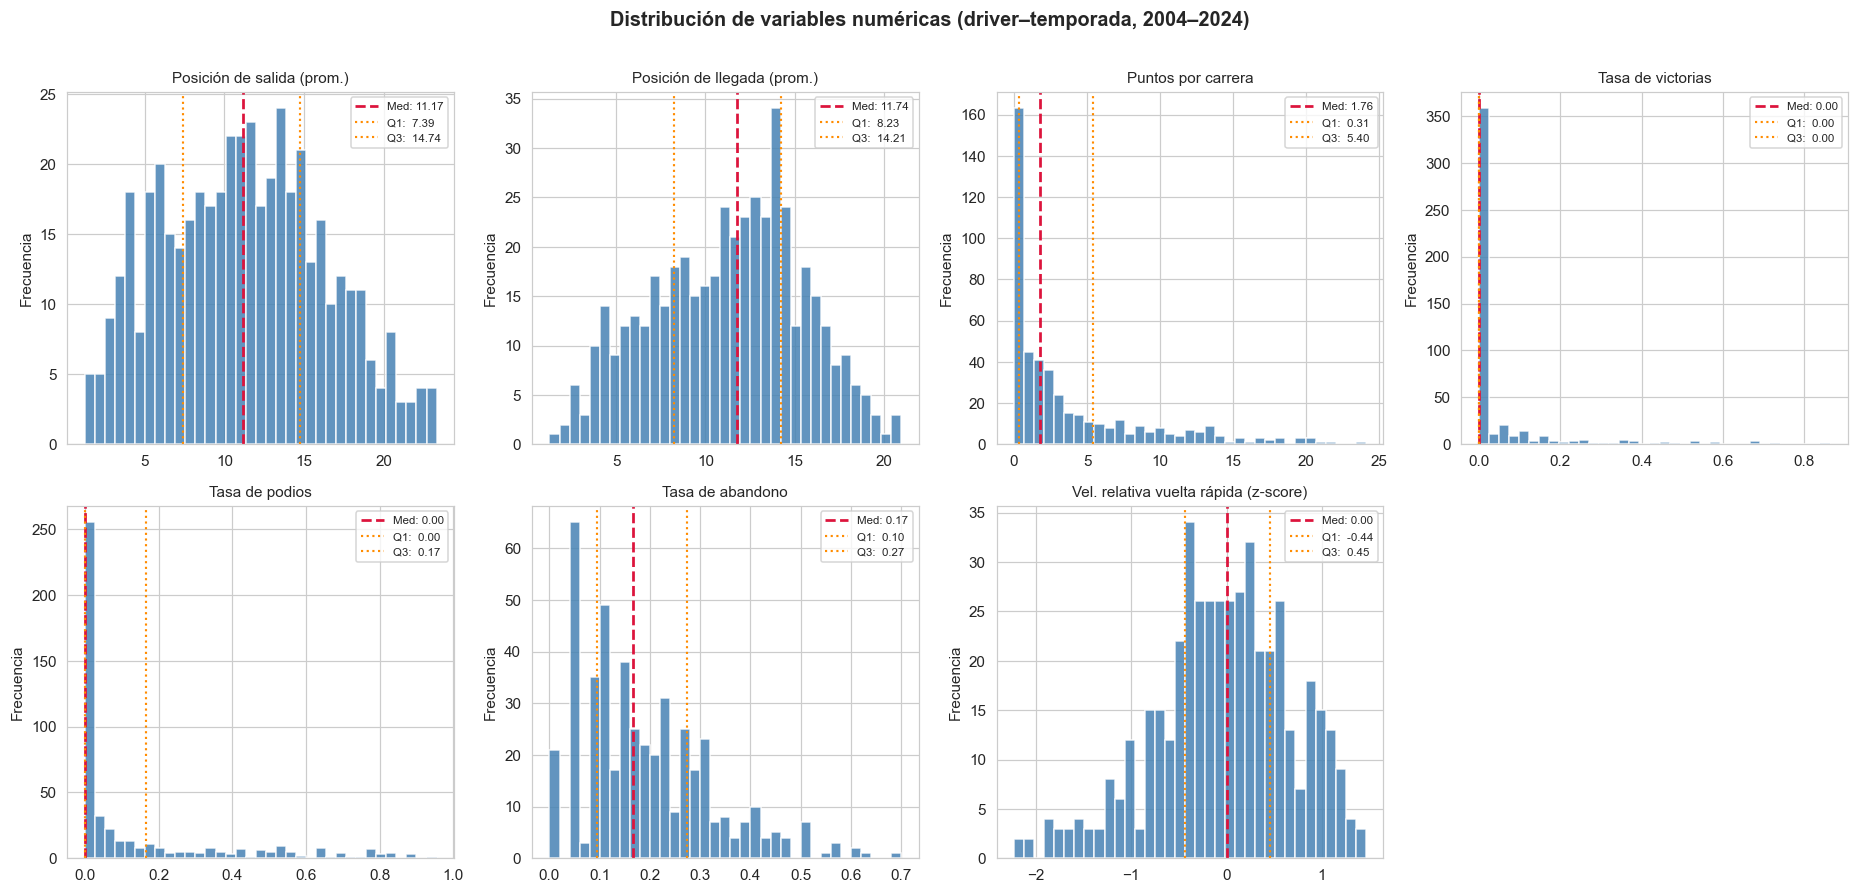

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.ravel()

for i, var in enumerate(NUMERIC_VARS):
    data = ds[var].dropna()
    q1, med, q3 = data.quantile([0.25, 0.5, 0.75])
    axes[i].hist(data, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(med, color='crimson',   linestyle='--', lw=1.8, label=f'Med: {med:.2f}')
    axes[i].axvline(q1,  color='darkorange', linestyle=':',  lw=1.4, label=f'Q1:  {q1:.2f}')
    axes[i].axvline(q3,  color='darkorange', linestyle=':',  lw=1.4, label=f'Q3:  {q3:.2f}')
    axes[i].set_title(VAR_LABELS[var], fontsize=10)
    axes[i].legend(fontsize=7.5)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
fig.suptitle('Distribución de variables numéricas (driver–temporada, 2004–2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'histogramas.png', bbox_inches='tight', dpi=150)
plt.show()

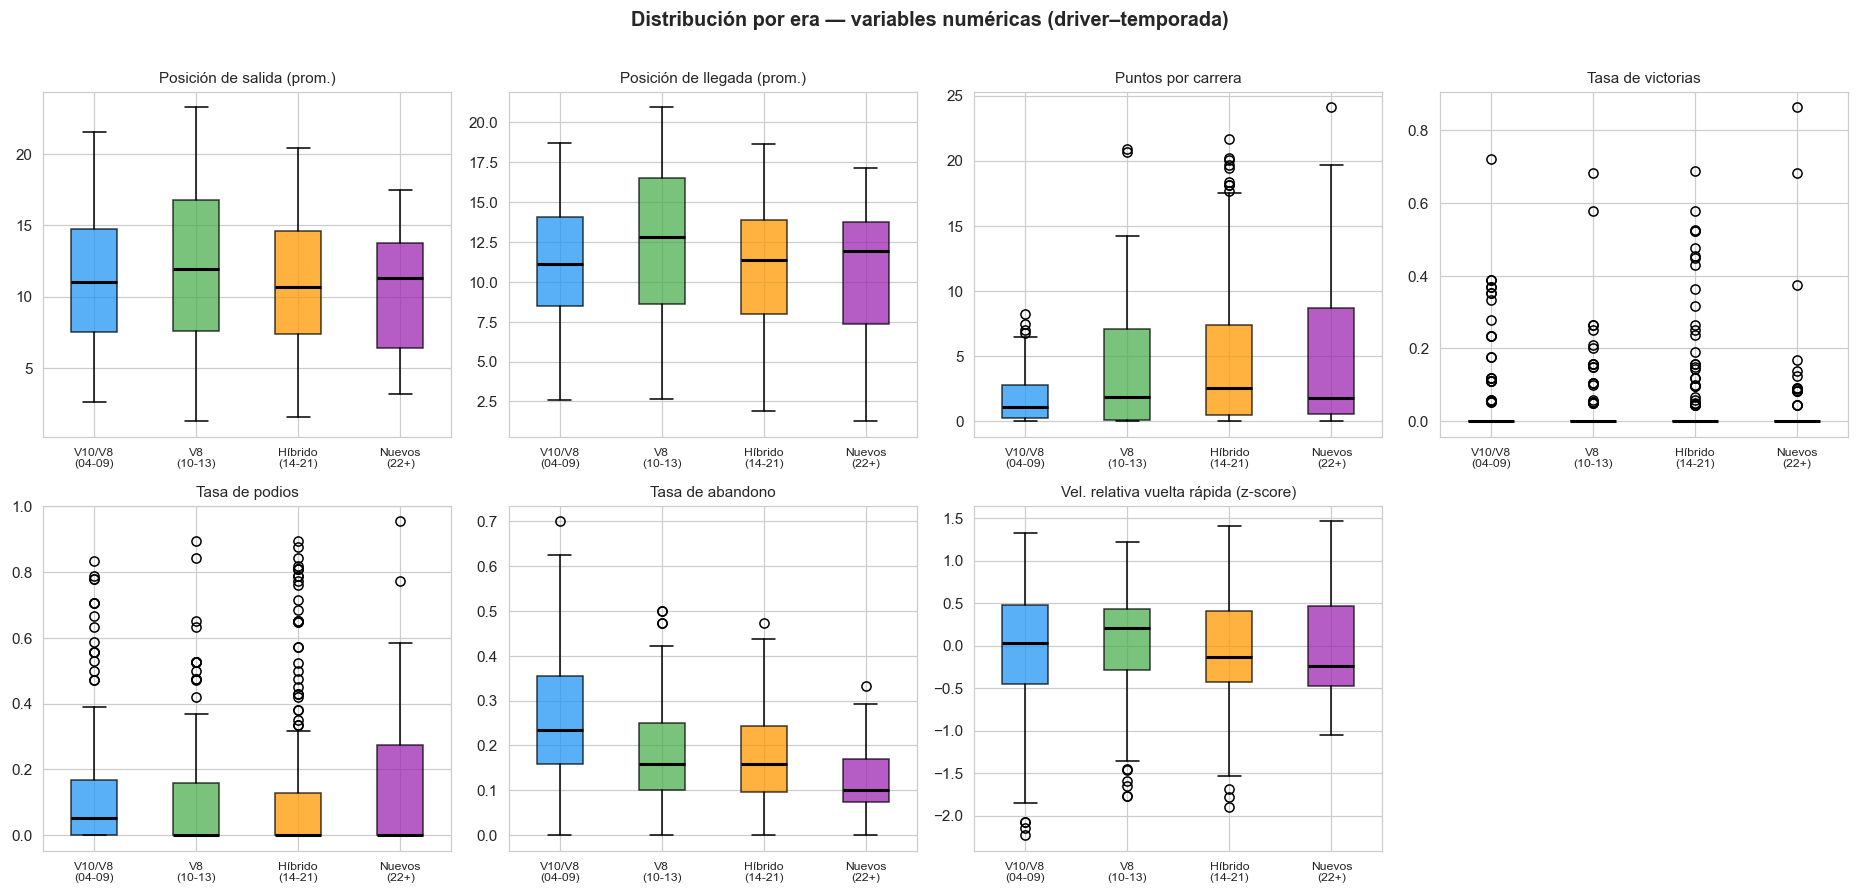

In [7]:
# Boxplots de variables numéricas por era
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.ravel()

for i, var in enumerate(NUMERIC_VARS):
    data_by_era = [ds[ds['era'] == e][var].dropna().values for e in ERA_ORDER]
    bp = axes[i].boxplot(data_by_era, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ERA_COLORS.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    axes[i].set_title(VAR_LABELS[var], fontsize=10)
    axes[i].set_xticklabels(['V10/V8\n(04-09)', 'V8\n(10-13)',
                              'Híbrido\n(14-21)', 'Nuevos\n(22+)'],
                             fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Distribución por era — variables numéricas (driver–temporada)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'boxplot_por_era.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Análisis Univariado — Variables categóricas

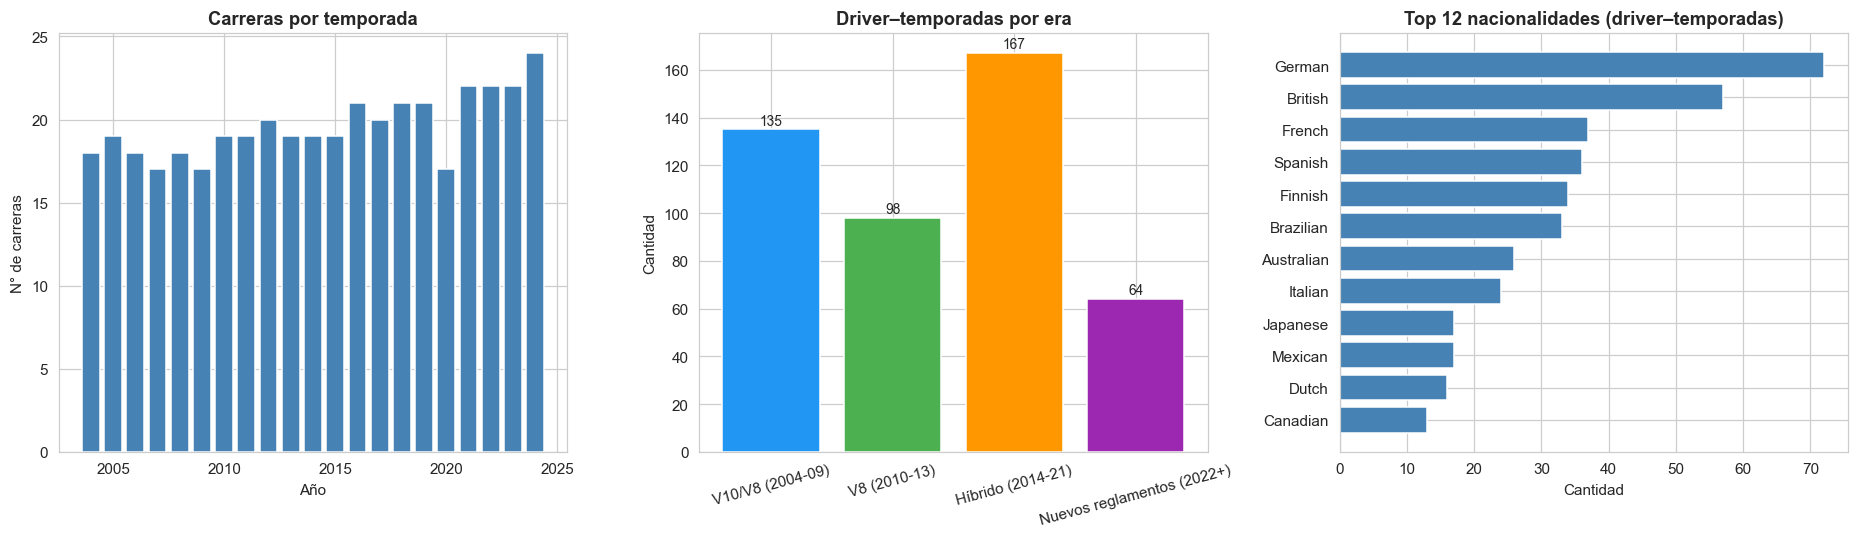

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Carreras por temporada
races_per_year = races[races['year'] >= 2004].groupby('year').size()
axes[0].bar(races_per_year.index, races_per_year.values, color='steelblue', edgecolor='white')
axes[0].set_title('Carreras por temporada', fontweight='bold')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('N° de carreras')

# Driver-temporadas por era
era_counts = ds['era'].value_counts().reindex(ERA_ORDER)
bars = axes[1].bar(era_counts.index, era_counts.values,
                   color=list(ERA_COLORS.values()), edgecolor='white')
for b, v in zip(bars, era_counts.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 2, str(v), ha='center', fontsize=9)
axes[1].set_title('Driver–temporadas por era', fontweight='bold')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=15)

# Top 12 nacionalidades
top_nat = ds['nationality'].value_counts().head(12)
axes[2].barh(top_nat.index[::-1], top_nat.values[::-1], color='steelblue', edgecolor='white')
axes[2].set_title('Top 12 nacionalidades (driver–temporadas)', fontweight='bold')
axes[2].set_xlabel('Cantidad')

plt.tight_layout()
plt.savefig(FIGS_PATH + 'categoricas_overview.png', bbox_inches='tight', dpi=150)
plt.show()

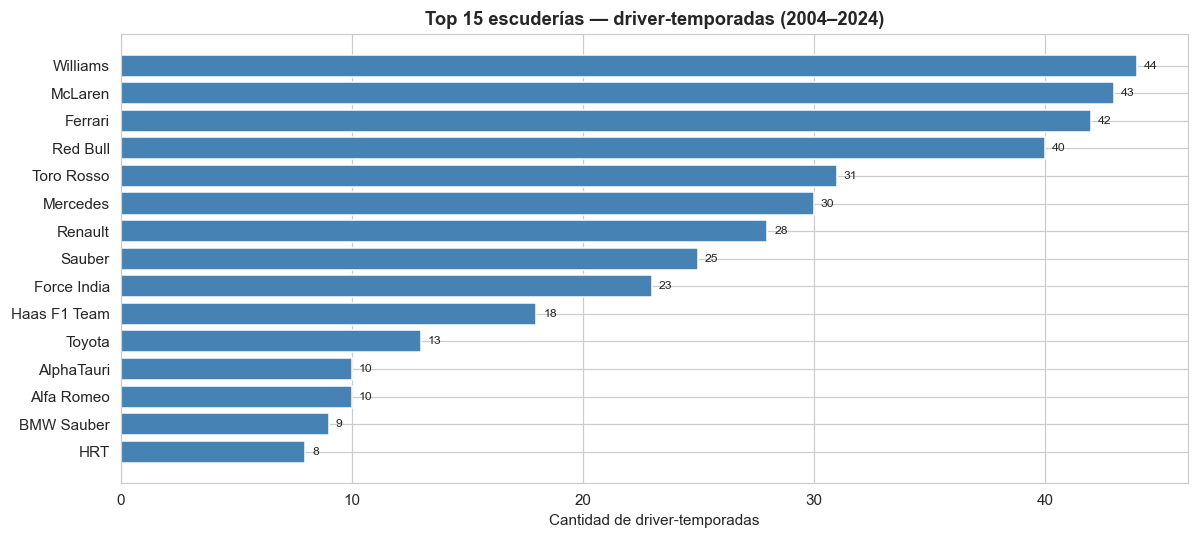

In [9]:
# Top 15 escuderías por apariciones en el dataset
fig, ax = plt.subplots(figsize=(11, 5))
top_constr = ds['constructor'].value_counts().head(15)
ax.barh(top_constr.index[::-1], top_constr.values[::-1], color='steelblue', edgecolor='white')
ax.set_title('Top 15 escuderías — driver-temporadas (2004–2024)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Cantidad de driver-temporadas')
for i, v in enumerate(top_constr.values[::-1]):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'top_constructores.png', bbox_inches='tight', dpi=150)
plt.show()

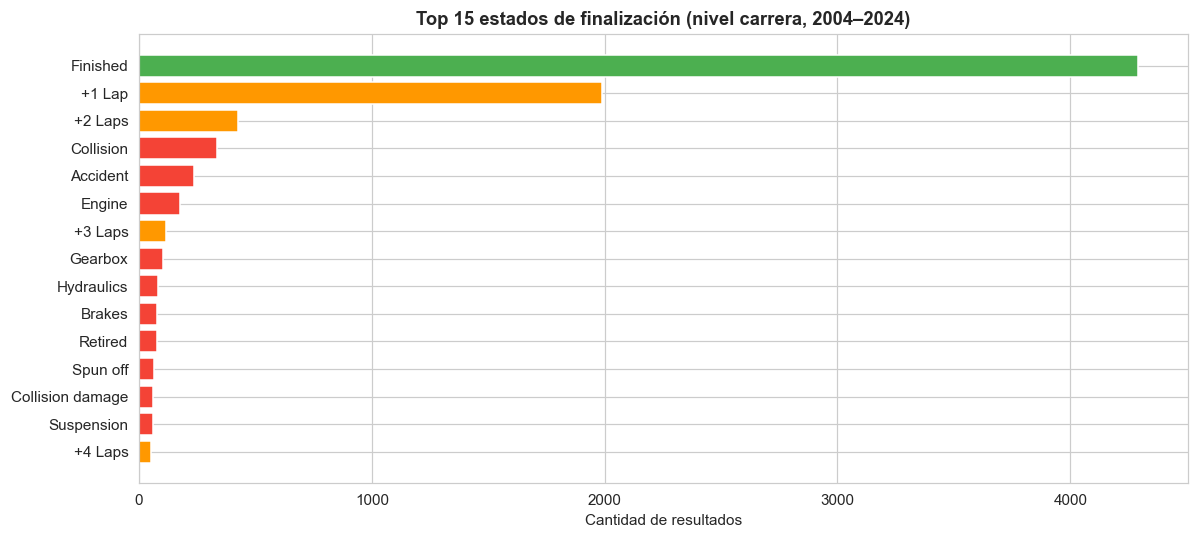

In [10]:
# Distribución del status de finalización (nivel carrera)
status_counts = df['status'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#4CAF50' if s == 'Finished' else
          '#FF9800' if '+' in s else '#F44336'
          for s in status_counts.index]
ax.barh(status_counts.index[::-1], status_counts.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Top 15 estados de finalización (nivel carrera, 2004–2024)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Cantidad de resultados')
plt.tight_layout()
plt.savefig(FIGS_PATH + 'status_finalizacion.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Análisis Bivariado

### 5.1 Matriz de correlaciones

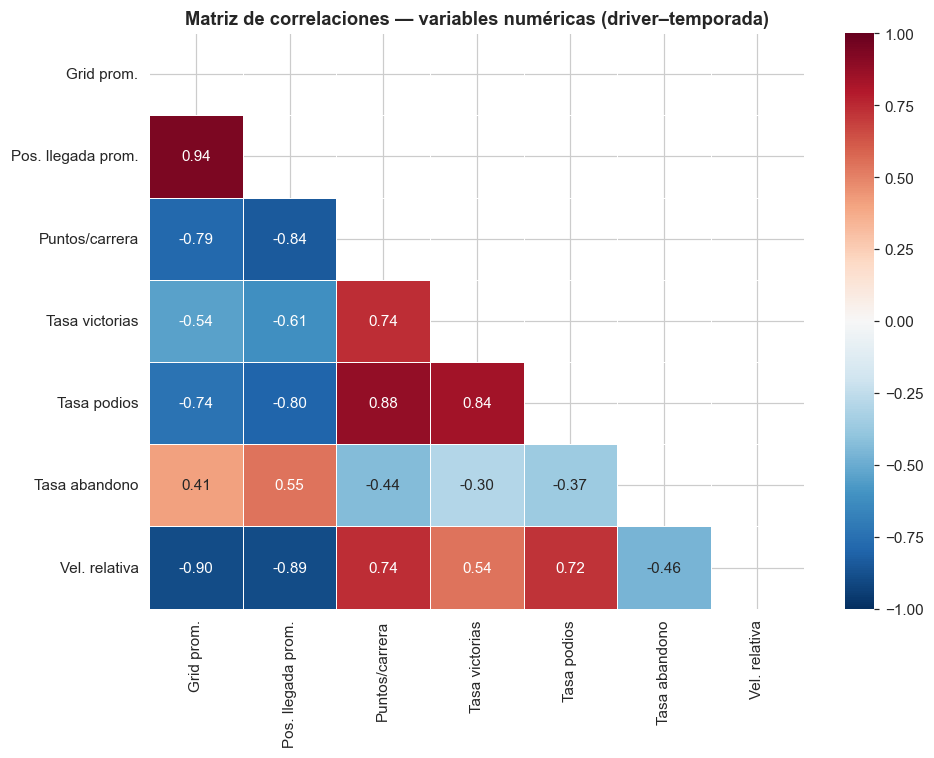

In [11]:
LABELS_SHORT = {
    'avg_grid':         'Grid prom.',
    'avg_pos_order':    'Pos. llegada prom.',
    'points_per_race':  'Puntos/carrera',
    'win_rate':         'Tasa victorias',
    'podium_rate':      'Tasa podios',
    'dnf_rate':         'Tasa abandono',
    'avg_rel_speed':    'Vel. relativa',
}

corr = ds[NUMERIC_VARS].corr()
corr_labeled = corr.rename(index=LABELS_SHORT, columns=LABELS_SHORT)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr_labeled, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, mask=mask, ax=ax,
            annot_kws={'size': 10}, linewidths=0.5)
ax.set_title('Matriz de correlaciones — variables numéricas (driver–temporada)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'correlacion.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.2 Scatter plots entre pares clave

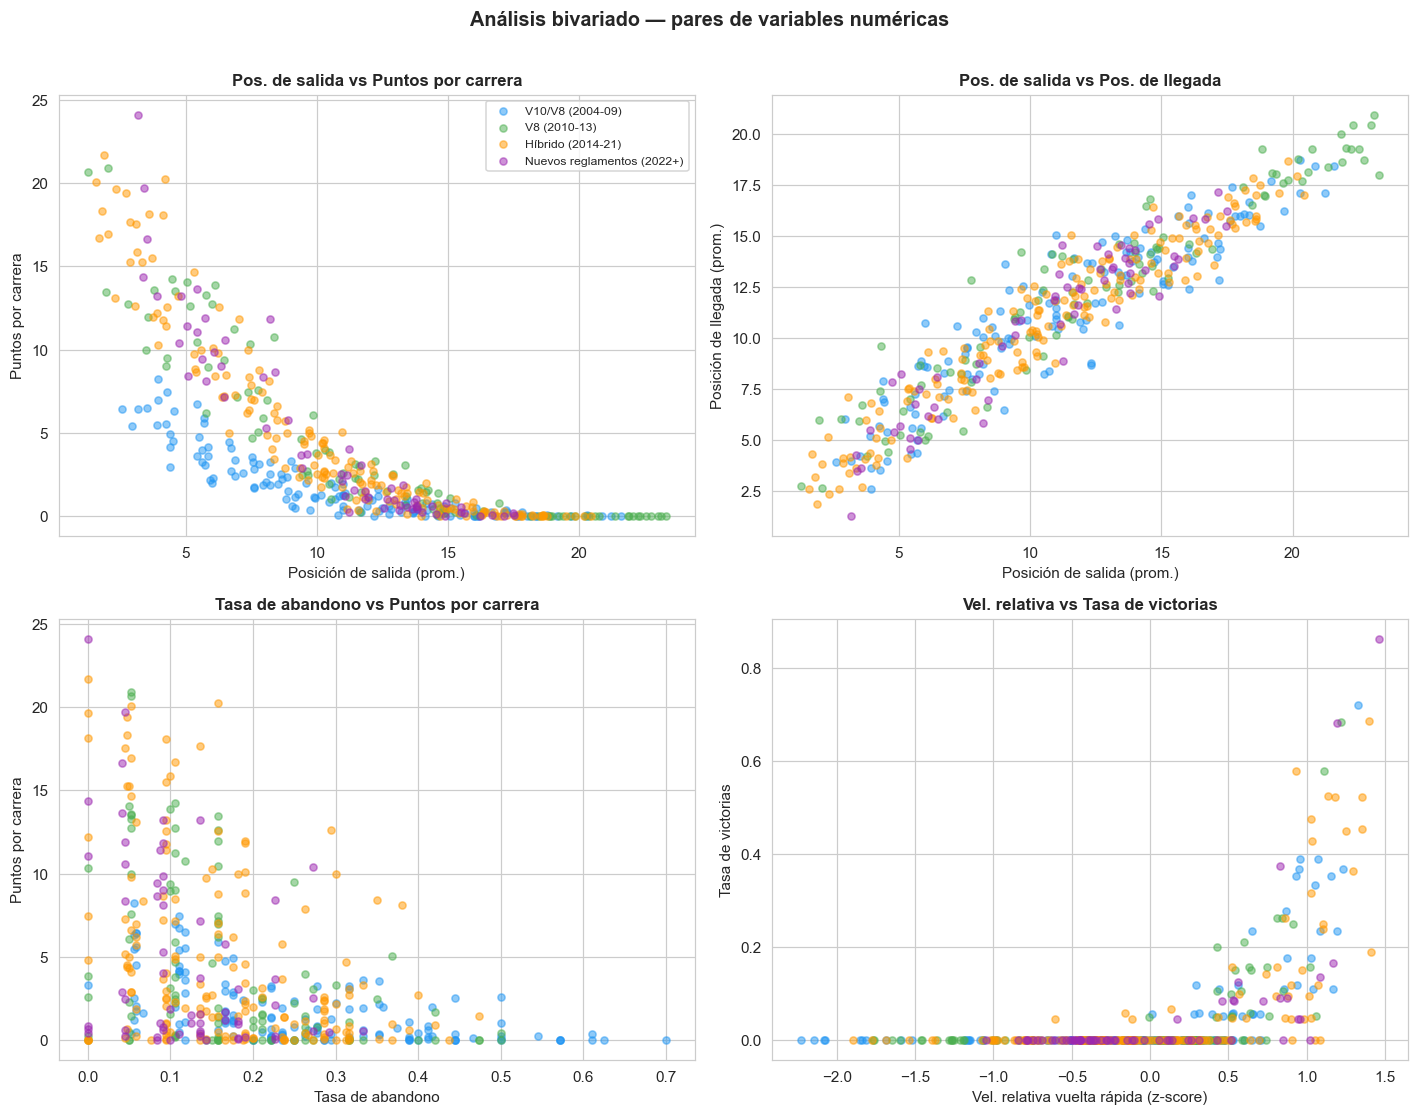

In [12]:
pairs = [
    ('avg_grid',        'points_per_race',  'Pos. de salida vs Puntos por carrera'),
    ('avg_grid',        'avg_pos_order',    'Pos. de salida vs Pos. de llegada'),
    ('dnf_rate',        'points_per_race',  'Tasa de abandono vs Puntos por carrera'),
    ('avg_rel_speed',   'win_rate',         'Vel. relativa vs Tasa de victorias'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for i, (xvar, yvar, title) in enumerate(pairs):
    for era in ERA_ORDER:
        grp = ds[ds['era'] == era].dropna(subset=[xvar, yvar])
        axes[i].scatter(grp[xvar], grp[yvar],
                        c=ERA_COLORS[era], label=era, alpha=0.5, s=22)
    axes[i].set_xlabel(VAR_LABELS[xvar], fontsize=10)
    axes[i].set_ylabel(VAR_LABELS[yvar], fontsize=10)
    axes[i].set_title(title, fontweight='bold', fontsize=11)
    if i == 0:
        axes[i].legend(fontsize=8, loc='upper right')

fig.suptitle('Análisis bivariado — pares de variables numéricas',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'scatter_pares.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.3 Puntos por carrera según posición de salida (grid decil)

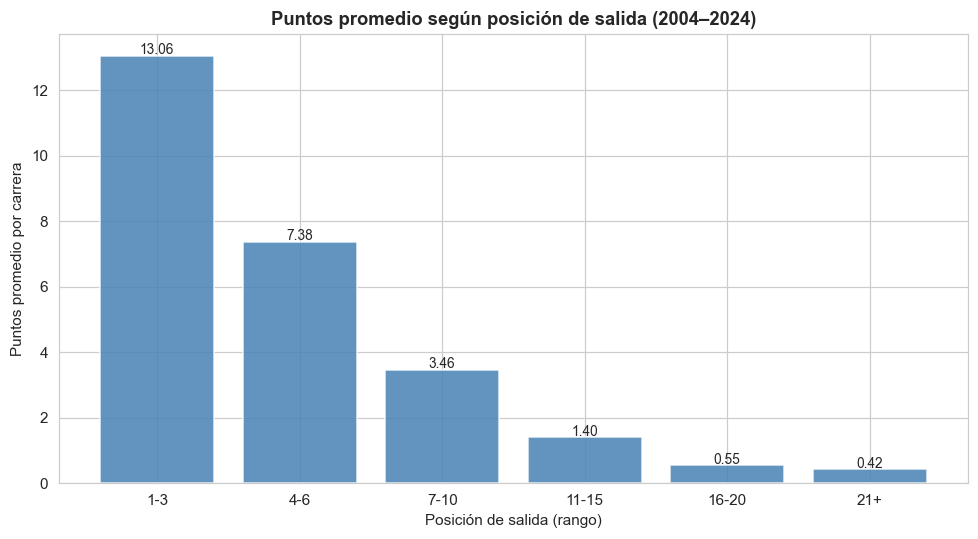

In [13]:
df_clean = df.dropna(subset=['grid', 'points']).copy()
df_clean['grid_bin'] = pd.cut(df_clean['grid'],
                               bins=[0, 3, 6, 10, 15, 20, 25],
                               labels=['1-3', '4-6', '7-10', '11-15', '16-20', '21+'])

pts_by_grid = df_clean.groupby('grid_bin', observed=True)['points'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pts_by_grid['grid_bin'].astype(str), pts_by_grid['points'],
       color='steelblue', edgecolor='white', alpha=0.85)
for i, (_, row) in enumerate(pts_by_grid.iterrows()):
    ax.text(i, row['points'] + 0.05, f"{row['points']:.2f}",
            ha='center', fontsize=9)
ax.set_xlabel('Posición de salida (rango)')
ax.set_ylabel('Puntos promedio por carrera')
ax.set_title('Puntos promedio según posición de salida (2004–2024)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'pts_por_grid.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.4 Tasa de DNF por era y posición de salida

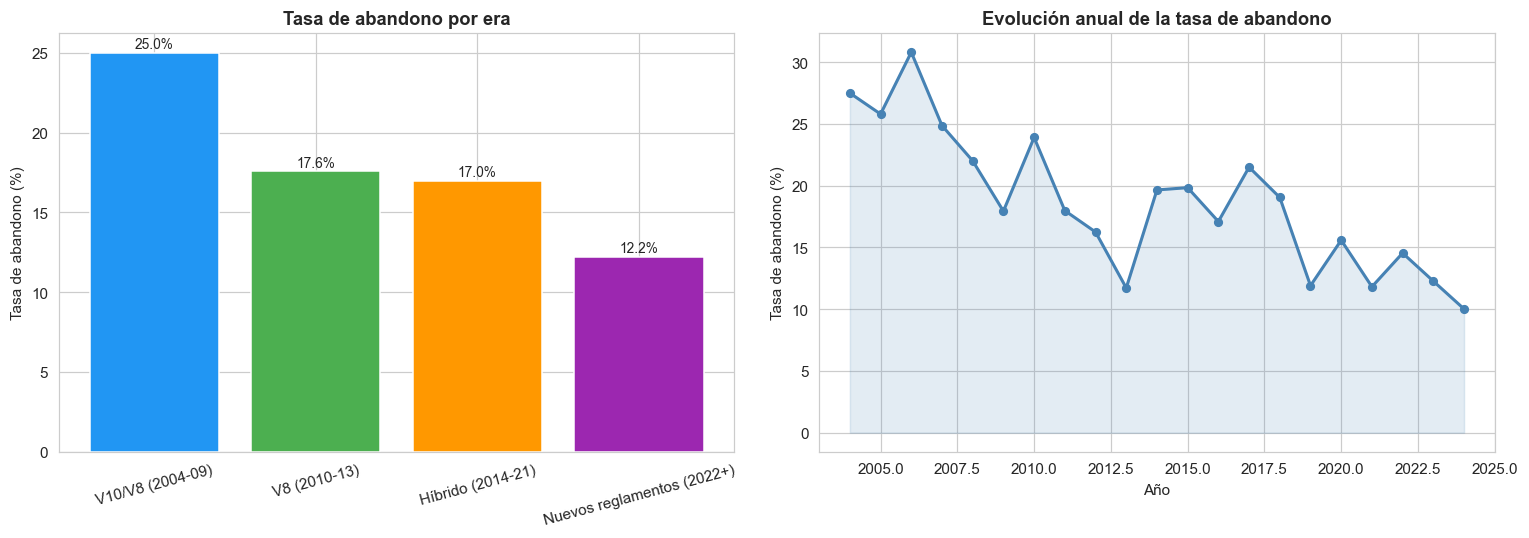

In [14]:
dnf_by_era = df.groupby('era')['is_dnf'].agg(['mean', 'count']).reindex(ERA_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DNF por era
bars = axes[0].bar(dnf_by_era.index, dnf_by_era['mean'] * 100,
                   color=list(ERA_COLORS.values()), edgecolor='white')
for b, v in zip(bars, dnf_by_era['mean'] * 100):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.3,
                 f'{v:.1f}%', ha='center', fontsize=9)
axes[0].set_ylabel('Tasa de abandono (%)')
axes[0].set_title('Tasa de abandono por era', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Evolución anual de DNF
dnf_year = df.groupby('year')['is_dnf'].mean() * 100
axes[1].plot(dnf_year.index, dnf_year.values, 'o-', color='steelblue',
             linewidth=2, markersize=5)
axes[1].fill_between(dnf_year.index, dnf_year.values, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Tasa de abandono (%)')
axes[1].set_title('Evolución anual de la tasa de abandono', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS_PATH + 'dnf_evolucion.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.5 Pit stops (2011–2024): cantidad y duración

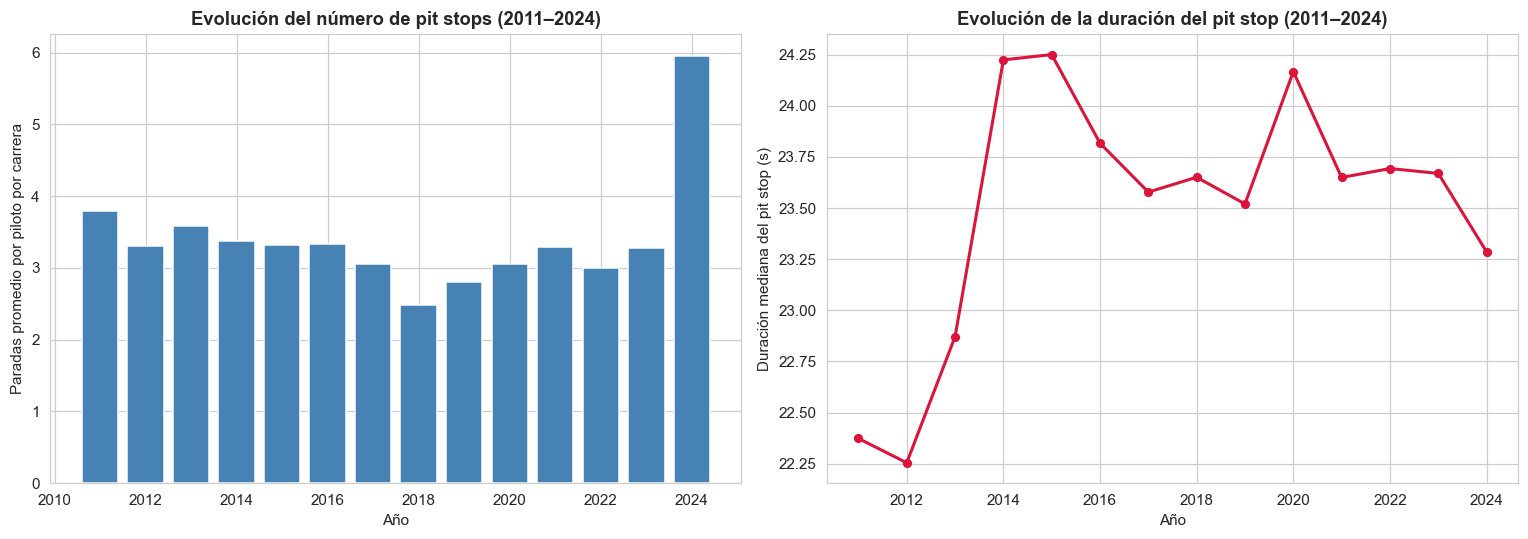

In [15]:
races_with_pits = races[races['raceId'].isin(pit_stops['raceId'])][['raceId', 'year']]
pit = pit_stops.merge(races_with_pits, on='raceId')
pit['duration'] = pd.to_numeric(pit['duration'].replace('\\N', np.nan), errors='coerce')
pit = pit[pit['duration'] < 60]  # descartar pit stops anómalos (> 1 min)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cantidad de pit stops por carrera por año
stops_per_race = pit.groupby(['raceId', 'year'])['stop'].max().reset_index()
avg_stops = stops_per_race.groupby('year')['stop'].mean()
axes[0].bar(avg_stops.index, avg_stops.values, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Paradas promedio por piloto por carrera')
axes[0].set_title('Evolución del número de pit stops (2011–2024)', fontweight='bold')

# Duración promedio anual
avg_dur = pit.groupby('year')['duration'].median()
axes[1].plot(avg_dur.index, avg_dur.values, 'o-', color='crimson',
             linewidth=2, markersize=5)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Duración mediana del pit stop (s)')
axes[1].set_title('Evolución de la duración del pit stop (2011–2024)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS_PATH + 'pit_stops.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.6 Puntos por temporada — top 10 pilotos históricos

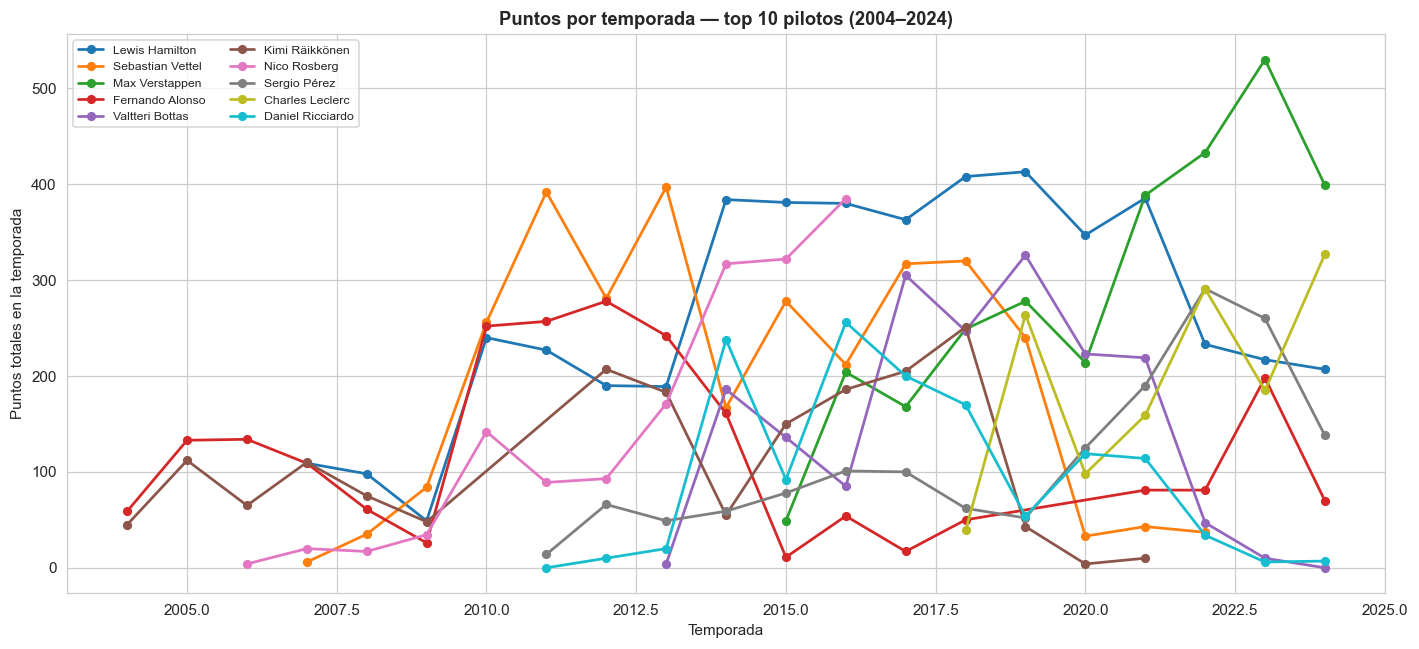

In [16]:
top10_drivers = (
    ds.groupby('driver_name')['total_points'].sum()
    .nlargest(10).index.tolist()
)

fig, ax = plt.subplots(figsize=(13, 6))
palette = plt.cm.tab10.colors

for i, driver in enumerate(top10_drivers):
    grp = ds[ds['driver_name'] == driver].sort_values('year')
    ax.plot(grp['year'], grp['total_points'], 'o-',
            label=driver, color=palette[i], linewidth=1.8, markersize=5)

ax.set_xlabel('Temporada')
ax.set_ylabel('Puntos totales en la temporada')
ax.set_title('Puntos por temporada — top 10 pilotos (2004–2024)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='upper left')
plt.tight_layout()
plt.savefig(FIGS_PATH + 'puntos_top10.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.7 Posiciones ganadas/perdidas vs puntos por carrera

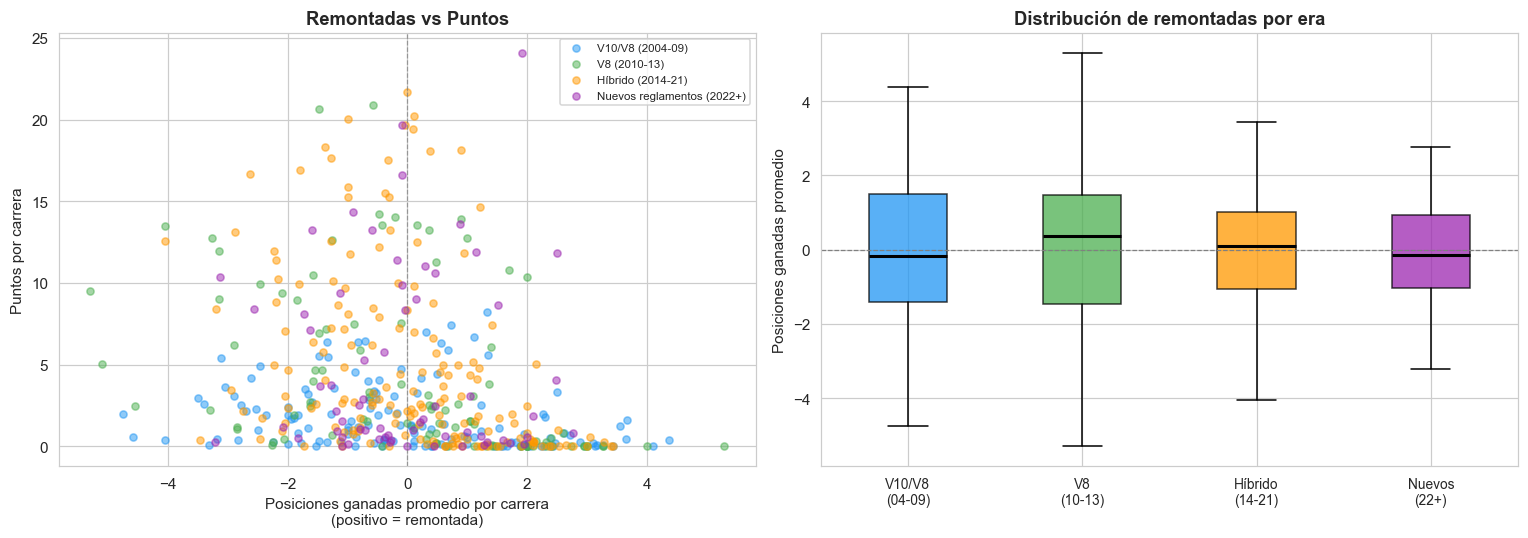

In [17]:
ds_clean = ds.dropna(subset=['avg_pos_gained', 'points_per_race', 'avg_rel_speed'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Posiciones ganadas vs puntos
for era in ERA_ORDER:
    grp = ds_clean[ds_clean['era'] == era]
    axes[0].scatter(grp['avg_pos_gained'], grp['points_per_race'],
                    c=ERA_COLORS[era], label=era, alpha=0.5, s=22)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].set_xlabel('Posiciones ganadas promedio por carrera\n(positivo = remontada)')
axes[0].set_ylabel('Puntos por carrera')
axes[0].set_title('Remontadas vs Puntos', fontweight='bold')
axes[0].legend(fontsize=7.5)

# Distribución de posiciones ganadas por era
data_by_era = [ds_clean[ds_clean['era'] == e]['avg_pos_gained'].dropna().values
               for e in ERA_ORDER]
bp = axes[1].boxplot(data_by_era, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ERA_COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xticklabels(['V10/V8\n(04-09)', 'V8\n(10-13)',
                          'Híbrido\n(14-21)', 'Nuevos\n(22+)'], fontsize=9)
axes[1].set_ylabel('Posiciones ganadas promedio')
axes[1].set_title('Distribución de remontadas por era', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS_PATH + 'posiciones_ganadas.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.8 Campeones: comparativa de variables clave

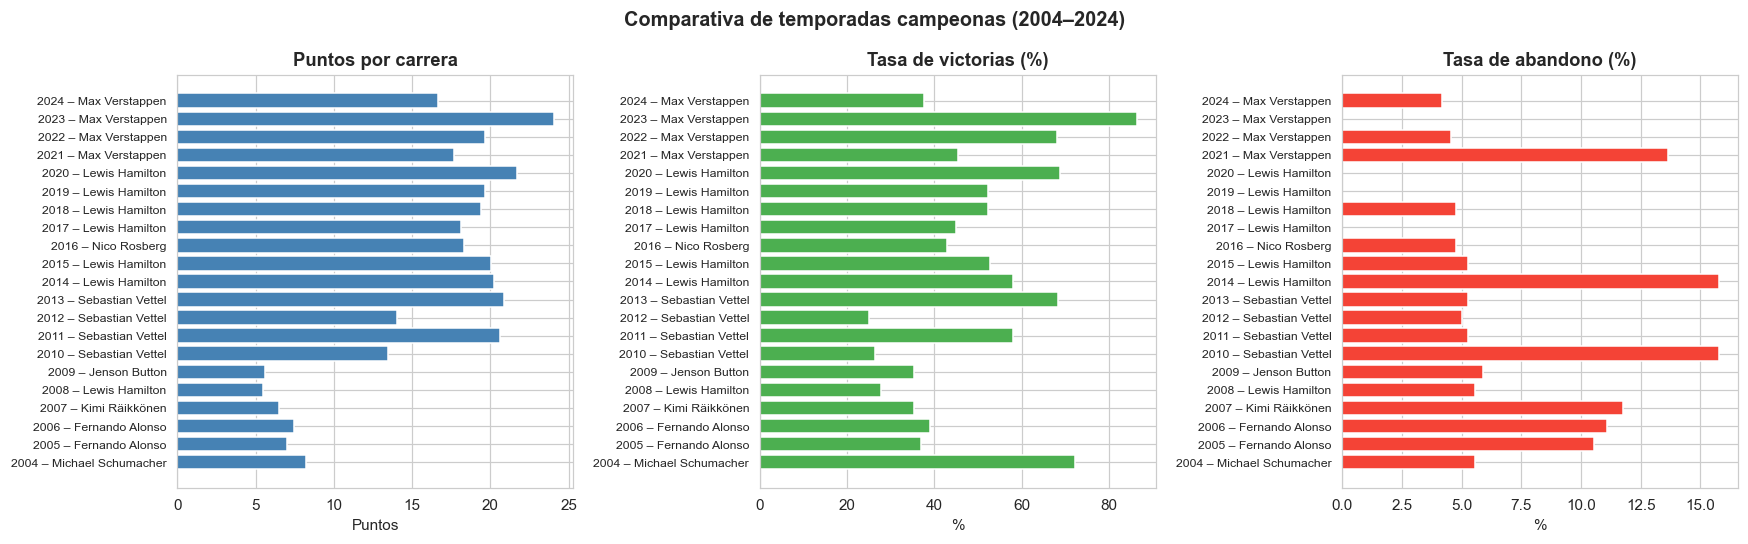

In [18]:
# Temporadas campeonas conocidas (desde 2004)
champions = {
    2004: ('Michael Schumacher', 2004),
    2005: ('Fernando Alonso', 2005),
    2006: ('Fernando Alonso', 2006),
    2007: ('Kimi Räikkönen', 2007),
    2008: ('Lewis Hamilton', 2008),
    2009: ('Jenson Button', 2009),
    2010: ('Sebastian Vettel', 2010),
    2011: ('Sebastian Vettel', 2011),
    2012: ('Sebastian Vettel', 2012),
    2013: ('Sebastian Vettel', 2013),
    2014: ('Lewis Hamilton', 2014),
    2015: ('Lewis Hamilton', 2015),
    2016: ('Nico Rosberg', 2016),
    2017: ('Lewis Hamilton', 2017),
    2018: ('Lewis Hamilton', 2018),
    2019: ('Lewis Hamilton', 2019),
    2020: ('Lewis Hamilton', 2020),
    2021: ('Max Verstappen', 2021),
    2022: ('Max Verstappen', 2022),
    2023: ('Max Verstappen', 2023),
    2024: ('Max Verstappen', 2024),
}

champ_rows = []
for yr, (name, y) in champions.items():
    row = ds[(ds['driver_name'] == name) & (ds['year'] == y)]
    if len(row):
        champ_rows.append(row.iloc[0])

champ_df = pd.DataFrame(champ_rows)[['driver_name', 'year', 'constructor',
                                      'points_per_race', 'win_rate',
                                      'podium_rate', 'dnf_rate']].copy()
champ_df = champ_df.sort_values('year')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(champ_df['year'].astype(str) + ' – ' + champ_df['driver_name'],
             champ_df['points_per_race'], color='steelblue', edgecolor='white')
axes[0].set_title('Puntos por carrera', fontweight='bold')
axes[0].set_xlabel('Puntos')

axes[1].barh(champ_df['year'].astype(str) + ' – ' + champ_df['driver_name'],
             champ_df['win_rate'] * 100, color='#4CAF50', edgecolor='white')
axes[1].set_title('Tasa de victorias (%)', fontweight='bold')
axes[1].set_xlabel('%')

axes[2].barh(champ_df['year'].astype(str) + ' – ' + champ_df['driver_name'],
             champ_df['dnf_rate'] * 100, color='#F44336', edgecolor='white')
axes[2].set_title('Tasa de abandono (%)', fontweight='bold')
axes[2].set_xlabel('%')

for ax in axes:
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Comparativa de temporadas campeonas (2004–2024)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS_PATH + 'temporadas_campeonas.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Valores atípicos

In [19]:
print("=== Temporadas con más puntos por carrera ===")
print(ds.nlargest(8, 'points_per_race')[['driver_name','year','constructor','points_per_race','win_rate']].to_string(index=False))

print("\n=== Temporadas con mayor tasa de abandono (≥5 carreras) ===")
print(ds.nlargest(8, 'dnf_rate')[['driver_name','year','constructor','dnf_rate','n_races']].to_string(index=False))

print("\n=== Mayor remontada promedio por temporada ===")
print(ds.dropna(subset=['avg_pos_gained']).nlargest(8, 'avg_pos_gained')
      [['driver_name','year','constructor','avg_pos_gained','avg_grid','avg_pos_order']].to_string(index=False))

=== Temporadas con más puntos por carrera ===
     driver_name  year constructor  points_per_race  win_rate
  Max Verstappen  2023    Red Bull        24.090909  0.863636
  Lewis Hamilton  2020    Mercedes        21.687500  0.687500
Sebastian Vettel  2013    Red Bull        20.894737  0.684211
Sebastian Vettel  2011    Red Bull        20.631579  0.578947
  Lewis Hamilton  2014    Mercedes        20.210526  0.578947
  Lewis Hamilton  2015    Mercedes        20.052632  0.526316
  Max Verstappen  2022    Red Bull        19.681818  0.681818
  Lewis Hamilton  2019    Mercedes        19.666667  0.523810

=== Temporadas con mayor tasa de abandono (≥5 carreras) ===
       driver_name  year constructor  dnf_rate  n_races
       Scott Speed  2007  Toro Rosso  0.700000       10
 Jaime Alguersuari  2009  Toro Rosso  0.625000        8
       Mark Webber  2006    Williams  0.611111       18
      Adrian Sutil  2008 Force India  0.611111       18
   Giorgio Pantano  2004      Jordan  0.571429       14

## 7. Resumen del dataset

In [20]:
print("="*55)
print("RESUMEN DEL DATASET")
print("="*55)
print(f"Período analizado:          2004–2024")
print(f"Carreras:                   {df['raceId'].nunique()}")
print(f"Pilotos únicos:             {df['driverId'].nunique()}")
print(f"Escuderías únicas:          {df['constructor'].nunique()}")
print(f"Resultados totales:         {len(df):,}")
print(f"Driver-temporadas (n≥5):    {len(ds)}")
print(f"  — con datos completos:    {ds[NUMERIC_VARS].dropna().shape[0]} (para PCA/Cluster)")
print()
print(f"Tasa de abandono global:    {df['is_dnf'].mean()*100:.1f}%")
print(f"Tasa de victoria:           {df['is_win'].mean()*100:.2f}%")
print(f"Tasa de podio:              {df['is_podium'].mean()*100:.1f}%")
print()
print("Variables numéricas para análisis multivariado:")
for v in NUMERIC_VARS:
    print(f"  {v:22s}: {ds[v].notna().sum()} obs. válidas")

RESUMEN DEL DATASET
Período analizado:          2004–2024
Carreras:                   412
Pilotos únicos:             108
Escuderías únicas:          35
Resultados totales:         8,650
Driver-temporadas (n≥5):    464
  — con datos completos:    464 (para PCA/Cluster)

Tasa de abandono global:    18.4%
Tasa de victoria:           4.76%
Tasa de podio:              14.3%

Variables numéricas para análisis multivariado:
  avg_grid              : 464 obs. válidas
  avg_pos_order         : 464 obs. válidas
  points_per_race       : 464 obs. válidas
  win_rate              : 464 obs. válidas
  podium_rate           : 464 obs. válidas
  dnf_rate              : 464 obs. válidas
  avg_rel_speed         : 464 obs. válidas
